In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpdaf.obj import Cube
from astropy.coordinates import SkyCoord
import sys
import os
import plotfancy as pf
from matplotlib.patches import Circle
from astropy.visualization import ZScaleInterval
from astropy.table import Table
from types import SimpleNamespace
import re
from astropy.io import ascii
from astropy import units as u
from astropy.table import Table, vstack, hstack
from scipy.optimize import curve_fit
from astropy.cosmology import WMAP9 as cosmo
from astropy import coordinates as coords
from astroquery.sdss import SDSS
from requests.exceptions import ConnectionError
from matplotlib.lines import Line2D
from hst_phot import *

# from calculate_jiang19_metallicity import calculate_metallicity_jiang19 as cjm19
sys.path.append('../../../')
import src.ifu_tools.line_ratios as lr

import logging 
logging.getLogger('mpdaf').setLevel(logging.WARNING)

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

pf.housestyle_rcparams()

True

In [2]:
rest_lambdas = {
# --- Primary [OIII] and [OII] ---
'oiii5007': 5006.84,
'oiii4959': 4958.91,
'oii3726':  3726.03,
'oii3729':  3728.82,

# --- Hydrogen Balmer Series ---
'halpha':   6562.80,
'hbeta':    4861.33,
'hgamma':   4340.46,
'hdelta':   4101.73,
'hepsilon': 3970.08,
'hzeta':    3889.06,
'heta':     3835.40,

# --- Key Diagnostic Lines ---
'oiii4363': 4363.21,
'neiii':    3868.75,

# --- Low-Ionization Lines ---
'nii6583':  6583.45,
'nii6548':  6548.05,
'sii6716':  6716.44,
'sii6731':  6730.82,

# --- Helium Lines ---
'heii4686': 4685.68,
'hei5876':  5875.62,
}
balmer_lambda = {
# 'halpha':   6562.80,
'hbeta':    4861.33,
'hgamma':   4340.46,
'hdelta':   4101.73,
'hepsilon': 3970.08,
'hzeta':    3889.06,
'heta':     3835.40,
}
lambda_keys = {
# --- Primary [OIII] and [OII] ---
'oiii5007': r'[OIII] $\lambda$5007',
'oiii4959': r'[OIII] $\lambda$4959',
'oii3726':  r'[OII] $\lambda$3726',
'oii3729':  r'[OII] $\lambda$3729',

# --- Hydrogen Balmer Series ---
'halpha':   r'H$\alpha$',
'hbeta':    r'H$\beta$',
'hgamma':   r'H$\gamma$',
'hdelta':   r'H$\delta$',
'hepsilon': r'H$\epsilon$',
'hzeta':    r'H$\zeta$',
'heta':     r'H$\eta$',

# --- Key Diagnostic Lines ---
'oiii4363': r'[OIII] $\lambda$4363',  # Auroral line
'neiii':    r'[NeIII] $\lambda$3869',

# --- Low-Ionization Lines ---
'nii6583':  r'[NII] $\lambda$6583',
'nii6548':  r'[NII] $\lambda$6548',
'sii6716':  r'[SII] $\lambda$6716',
'sii6731':  r'[SII] $\lambda$6731',

# --- Helium Lines (not forbidden) ---
'heii4686': r'HeII $\lambda$4686',
'hei5876':  r'HeI $\lambda$5876',
}

In [3]:
test = ascii.read('allsources.csv')
tab = test[test['object_id']!= 'STACK']
f = False
if f:
    fixed = 'fixed'
    tab['oiii4959_flux']=tab['oiii5007_flux']/3
else:
    fixed=''

In [4]:
tab

object_id,ra,dec,z,angdisp,foreground,cluster_member,lensed,Z_dir,Z_dir_e,Z_j19,Z_j19_e,R23,R23_e,mean_vel_disp,sterr_vel_disp,zcluster,name,oiii5007_flux,oiii5007_flux_err,oiii5007_ew,oiii5007_ew_err,oiii5007_centroid,oiii5007_fwhm,oiii5007_vel_disp,oiii4959_flux,oiii4959_flux_err,oiii4959_ew,oiii4959_ew_err,oiii4959_centroid,oiii4959_fwhm,oiii4959_vel_disp,oii3726_flux,oii3726_flux_err,oii3726_ew,oii3726_ew_err,oii3726_centroid,oii3726_fwhm,oii3726_vel_disp,oii3729_flux,oii3729_flux_err,oii3729_ew,oii3729_ew_err,oii3729_centroid,oii3729_fwhm,oii3729_vel_disp,halpha_flux,halpha_flux_err,halpha_ew,halpha_ew_err,halpha_centroid,halpha_fwhm,halpha_vel_disp,hbeta_flux,hbeta_flux_err,hbeta_ew,hbeta_ew_err,hbeta_centroid,hbeta_fwhm,hbeta_vel_disp,hgamma_flux,hgamma_flux_err,hgamma_ew,hgamma_ew_err,hgamma_centroid,hgamma_fwhm,hgamma_vel_disp,hdelta_flux,hdelta_flux_err,hdelta_ew,hdelta_ew_err,hdelta_centroid,hdelta_fwhm,hdelta_vel_disp,hepsilon_flux,hepsilon_flux_err,hepsilon_ew,hepsilon_ew_err,hepsilon_centroid,hepsilon_fwhm,hepsilon_vel_disp,hzeta_flux,hzeta_flux_err,hzeta_ew,hzeta_ew_err,hzeta_centroid,hzeta_fwhm,hzeta_vel_disp,heta_flux,heta_flux_err,heta_ew,heta_ew_err,heta_centroid,heta_fwhm,heta_vel_disp,oiii4363_flux,oiii4363_flux_err,oiii4363_ew,oiii4363_ew_err,oiii4363_centroid,oiii4363_fwhm,oiii4363_vel_disp,neiii_flux,neiii_flux_err,neiii_ew,neiii_ew_err,neiii_centroid,neiii_fwhm,neiii_vel_disp,nii6583_flux,nii6583_flux_err,nii6583_ew,nii6583_ew_err,nii6583_centroid,nii6583_fwhm,nii6583_vel_disp,nii6548_flux,nii6548_flux_err,nii6548_ew,nii6548_ew_err,nii6548_centroid,nii6548_fwhm,nii6548_vel_disp,sii6716_flux,sii6716_flux_err,sii6716_ew,sii6716_ew_err,sii6716_centroid,sii6716_fwhm,sii6716_vel_disp,sii6731_flux,sii6731_flux_err,sii6731_ew,sii6731_ew_err,sii6731_centroid,sii6731_fwhm,sii6731_vel_disp,heii4686_flux,heii4686_flux_err,heii4686_ew,heii4686_ew_err,heii4686_centroid,heii4686_fwhm,heii4686_vel_disp,hei5876_flux,hei5876_flux_err,hei5876_ew,hei5876_ew_err,hei5876_centroid,hei5876_fwhm,hei5876_vel_disp
str29,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str12,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
28d07m28pt35s-28d53m18pt439s,28.124541666666662,-28.888455277777776,0.3685089804926993,26.18756698942221,1,0,0,nan,nan,8.141642654203588,0.004260300187639276,11.062827619803281,2.277642553607944,717.2840511320709,242.072037707888,0.4127,macs0152m28,4124.469894464831,87.899338157534,35.219154485348156,2.0501406651496796,5006.835951321285,2.000851928624639,47.66104780419961,1185.2825861364677,136.72975380269563,5.898970866095592,1.8880619600846873,4958.900222500991,1.6770166740703585,39.12405443693391,1761.464896696335,1068.6135356727189,29.998235596428906,91.72048342399984,3725.300846892047,5.449503026807009,184.65485291083476,2884.5577145722427,1618.3931634975047,49.243829643832576,138.90878074330303,3728.766711514383,5.449503026807009,184.516

(array([0.11094891, 0.        , 0.        , 0.05547445, 0.05547445,
        0.05547445, 0.38832117, 0.27737226, 0.88759124, 0.77664234,
        1.49781022, 1.22043796, 0.94306569, 0.33284672, 0.33284672,
        0.22189781, 0.27737226, 0.11094891, 0.05547445]),
 array([0.        , 0.13157895, 0.26315789, 0.39473684, 0.52631579,
        0.65789474, 0.78947368, 0.92105263, 1.05263158, 1.18421053,
        1.31578947, 1.44736842, 1.57894737, 1.71052632, 1.84210526,
        1.97368421, 2.10526316, 2.23684211, 2.36842105, 2.5       ]),
 <BarContainer object of 19 artists>)

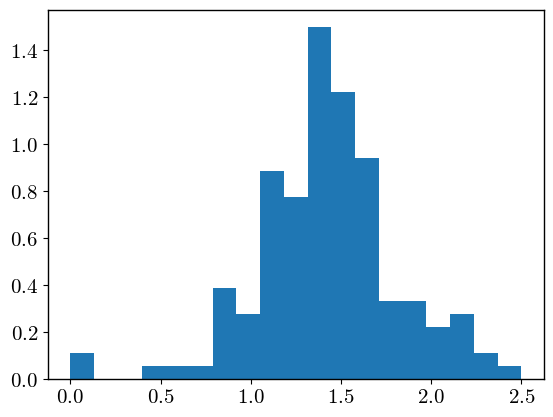

In [5]:
rat = tab['oii3729_flux']/tab['oii3726_flux']
mask = np.isfinite(rat)
plt.hist(rat[mask], bins=np.linspace(0,2.5,20), density=True)

(array([0.08507463, 0.        , 0.02835821, 0.09925373, 0.05671642,
        0.29776119, 0.38283582, 0.26940299, 0.17014925, 0.19850746,
        0.11343284, 0.0141791 , 0.02835821, 0.04253731, 0.        ,
        0.02835821, 0.02835821, 0.04253731, 0.0141791 ]),
 array([ 0.        ,  0.52631579,  1.05263158,  1.57894737,  2.10526316,
         2.63157895,  3.15789474,  3.68421053,  4.21052632,  4.73684211,
         5.26315789,  5.78947368,  6.31578947,  6.84210526,  7.36842105,
         7.89473684,  8.42105263,  8.94736842,  9.47368421, 10.        ]),
 <BarContainer object of 19 artists>)

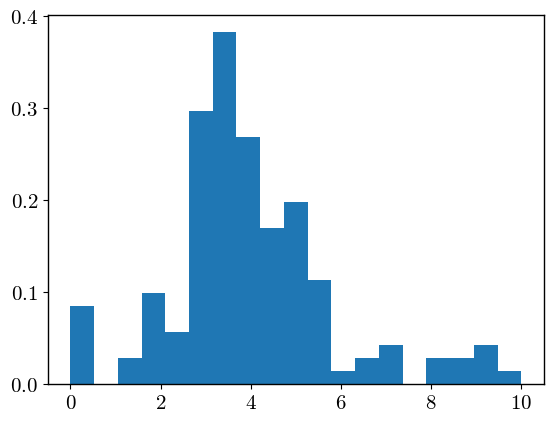

In [6]:
rat = tab['oiii5007_flux']/tab['oiii4959_flux']
mask1 = np.isfinite(rat)
plt.hist(rat[mask1], bins=np.linspace(0,10,20), density=True)

(array([0.08860759, 0.17721519, 0.22151899, 0.48734177, 0.53164557,
        0.97468354, 3.10126582, 0.93037975, 0.22151899, 0.08860759,
        0.0443038 , 0.0443038 , 0.0443038 , 0.0443038 ]),
 array([0.        , 0.14285714, 0.28571429, 0.42857143, 0.57142857,
        0.71428571, 0.85714286, 1.        , 1.14285714, 1.28571429,
        1.42857143, 1.57142857, 1.71428571, 1.85714286, 2.        ]),
 <BarContainer object of 14 artists>)

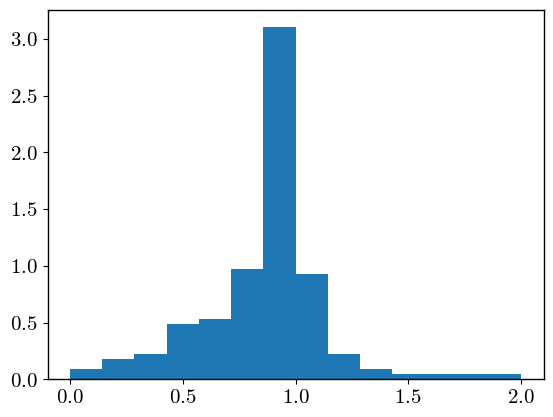

In [7]:
R23 = (tab['oiii5007_flux'] + tab['oiii4959_flux'] +  tab['oii3729_flux'] + tab['oii3726_flux'])/tab['hbeta_flux']
mask2 = np.isfinite(R23)
plt.hist(np.log10(R23[mask2]), density=True, bins=np.linspace(0,2,15))

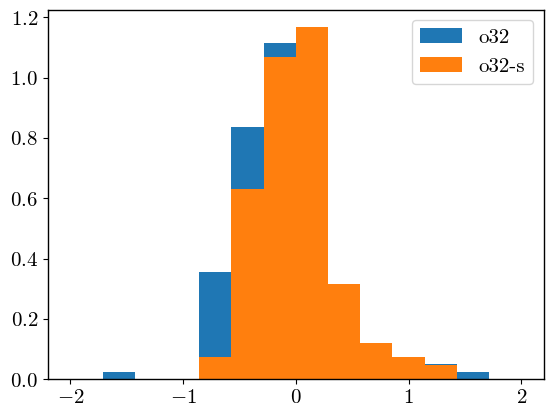

In [8]:
O32 = (tab['oiii5007_flux'] + tab['oiii4959_flux'])/((tab['oii3729_flux'] + tab['oii3726_flux']))
O32_s = (tab['oiii5007_flux'])/(tab['oii3729_flux'])
mask3 = np.isfinite(O32)
mask_s = np.isfinite(O32_s)
plt.hist(np.log10(O32[mask3]), density=True, bins=np.linspace(-2,2,15), label=r'o32')
plt.hist(np.log10(O32_s[mask_s]), density=True, bins=np.linspace(-2,2,15), label=r'o32-s')
plt.legend()

/var/folders/6b/x84gj0ds47n3hjglw1wq1j8m0000gn/T/ipykernel_64970/2982374047.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


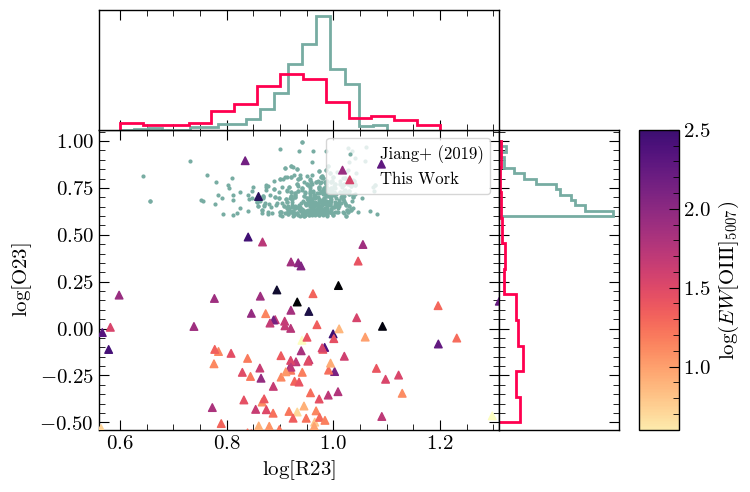

In [9]:
fig, ax = pf.create_plot()
ax.set_xlabel(r'$\log[\mathrm{R23}]$')
ax.set_ylabel(r'$\log[\mathrm{O23}]$')


ax1 = fig.add_axes([1,0,0.3,1], sharey=ax)
plt.setp(ax1.get_yticklabels(), visible=False)
ax2 = fig.add_axes([0,1,1,0.4], sharex=ax)
plt.setp(ax2.get_xticklabels(), visible=False)

cax = fig.add_axes([1.35,0,0.1,1])
cax.set_ylabel(r'$\log(EW\mathrm{[OIII]}_{5007})$')
cax.yaxis.set_label_position("right")

jiang_table = ascii.read('jiang_colorplot_data.csv')
O32_j = jiang_table['y']
R23_j = jiang_table['x']
cm = np.isfinite(tab['oiii5007_ew'])

ax.scatter(R23_j, O32_j, c='#77aca2', s=4, label='Jiang+ (2019)')
scatter = ax.scatter(np.log10(R23)[cm],np.log10(O32)[cm], s=30, marker='^',zorder=10, c=np.log10(tab['oiii5007_ew'])[cm], cmap='magma_r',vmax=3, vmin=.5, label='This Work')
cbar = fig.colorbar(scatter, ax=ax, cax=cax, label=r'$\log(EW\mathrm{[OIII]}_{5007})$')

xlims = np.array([0.5,1.25])
ylims = np.array([-0.6,1])

ax.set_xlim(xlims+0.06)
ax.set_ylim(ylims+0.06)
ax1.set_xticks([])
ax2.set_yticks([])
cax.set_ylim(0.6,2.5)


ax1.hist(O32_j, bins=np.linspace(0.6,1,15), density=True, orientation='horizontal', histtype='step', lw=2, ec='#77aca2')
ax2.hist(R23_j, bins=np.linspace(0.6,1.1,20), density=True, orientation='vertical', histtype='step', lw=2, ec='#77aca2')

ax1.hist(np.log10(O32), bins=np.linspace(-0.5,1,12), density=True, orientation='horizontal', histtype='step', lw=2, ec='#ff004f')
ax2.hist(np.log10(R23), bins=np.linspace(0.6,1.2,15), density=True, orientation='vertical', histtype='step', lw=2, ec='#ff004f')

ax.legend(loc='upper right', fontsize=12)

pf.fix_plot([ax,ax1,ax2,cax])

plt.tight_layout()
plt.savefig(f'figs/r23o32_{fixed}.png', dpi=600,bbox_inches='tight')


(array([ 1.,  7., 14., 29., 11.,  6.,  3.,  1.,  0.]),
 array([1.        , 1.44444444, 1.88888889, 2.33333333, 2.77777778,
        3.22222222, 3.66666667, 4.11111111, 4.55555556, 5.        ]),
 <BarContainer object of 9 artists>)

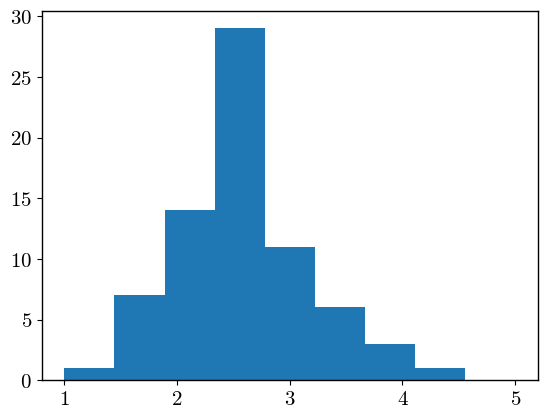

In [10]:
plt.hist(tab['halpha_flux']/tab['hbeta_flux'], bins=np.linspace(1,5, 10))

(array([ 2., 30., 12., 20., 32., 21., 10.,  5.,  5.]),
 array([-1.        , -0.33333333,  0.33333333,  1.        ,  1.66666667,
         2.33333333,  3.        ,  3.66666667,  4.33333333,  5.        ]),
 <BarContainer object of 9 artists>)

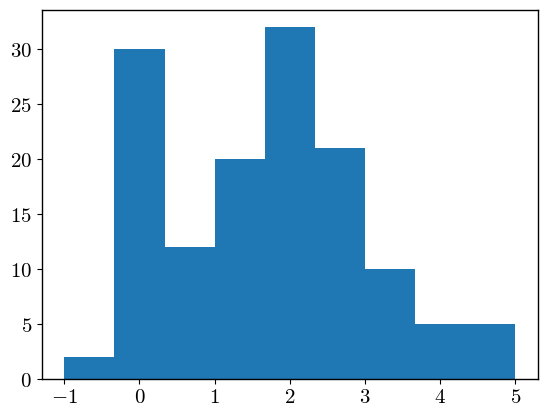

In [11]:
plt.hist(tab['hbeta_flux']/tab['hgamma_flux'], bins=np.linspace(-1,5, 10))

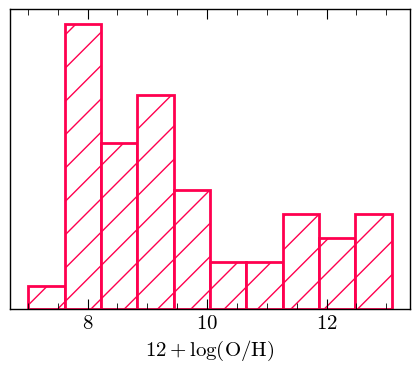

In [12]:
fig, ax = pf.create_plot()
ax.hist(tab['Z_dir'], lw=2, density=True, edgecolor='#ff004f', hatch="/", facecolor='white')
pf.fix_plot([ax])
ax.set_yticks([])
ax.set_xlabel(r'$12+\log(\mathrm{O/H})$')
fig.savefig(f'figs/metallicity_{fixed}.png', dpi=600, bbox_inches='tight')

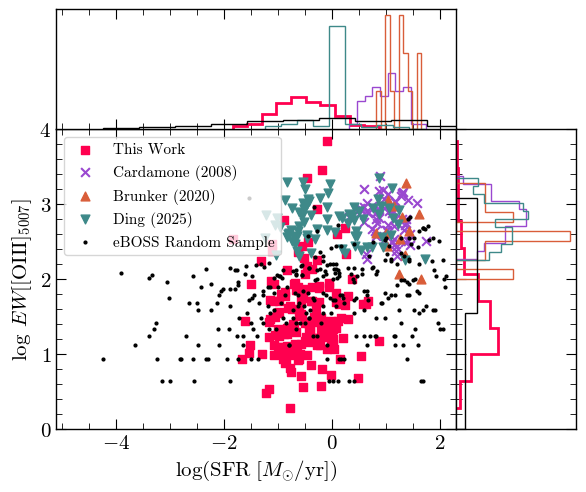

In [13]:
z = tab['z']
D_L = cosmo.luminosity_distance(z)
D_L_cm = D_L.to(u.cm).value
L_hbeta = tab['hbeta_flux'] * 4 * np.pi * (D_L_cm**2)*1e-20
SFR = (7.9e-42*L_hbeta)*2.86 #kennicutt 1998 hbeta with halpha ratio

tab2 = Table(ascii.read('wpd_datasets.csv'), names=['c_x','c_y','b_x','b_y','d_x','d_y','e_x','e_y'])
cardamone = tab2['c_x'], tab2['c_y']
brunker = tab2['b_x'], tab2['b_y']
ding = tab2['d_x'], tab2['d_y']
eboss = tab2['e_x'], tab2['e_y']

datz = [cardamone,brunker,ding,eboss]
labz = ['Cardamone (2008)','Brunker (2020)', 'Ding (2025)', 'eBOSS Random Sample']
mkz = ['x','^','v','o']
colours = ['#9A48D0','#D95D39','#3E8989','k']
binz = [np.linspace(0,2,10),np.linspace(0.5,2,5), np.linspace(-2,2,10), np.linspace(-4,2,10)]

fig,ax= pf.create_plot()
ax1 = fig.add_axes([1,0,0.3,1], sharey=ax)
plt.setp(ax1.get_yticklabels(), visible=False)
ax2 = fig.add_axes([0,1,1,0.4], sharex=ax)
plt.setp(ax2.get_xticklabels(), visible=False)

mask = np.isfinite(np.log10(SFR))
ax.scatter(np.log10(SFR)[mask], np.log10(tab['oiii5007_ew'])[mask], label='This Work', marker='s', c='#ff004f', s=40)
ax1.hist( np.log10(tab['oiii5007_ew'])[mask], histtype='step', orientation='horizontal', lw=2, color='#ff004f', density=True, bins=10)
ax2.hist(np.log10(SFR)[mask], histtype='step', orientation='vertical', lw=2, color='#ff004f', density=True, bins=10)


for i,d in enumerate(datz):
    log10sfr_str = d[1][2:].data
    ew_str = d[0][2:].data 

    global dat
    dat = []

    for a in [log10sfr_str,ew_str]:
        if type(a) == np.ma.MaskedArray:
            a.set_fill_value(np.nan)
        dat.append(a.astype(np.float64))

    ax.scatter(dat[0],np.log10(dat[1]), label=labz[i], marker=mkz[i], s=(40 if i<3 else 4), color=colours[i])

    mask0 = np.isfinite(dat[0])
    mask1 = np.isfinite(dat[1])

    ax1.hist(np.log10(dat[1])[mask0], histtype='step', orientation='horizontal', lw=1, color=colours[i], density=True, bins=10)
    ax2.hist(dat[0][mask1],histtype='step', orientation='vertical', lw=1, color=colours[i], density=True, bins=10)
    
ax.set_ylim(0,4)
ax.set_xlim(-5.1,2.3)
ax.legend(fontsize=11)
ax.set_xlabel(r'$\log(\mathrm{SFR}\;[M_{\odot}/\mathrm{yr}])$')
ax.set_ylabel(r'$\log\;EW[\mathrm{[OIII]_{5007}}]$')

ax1.set_xticks([])
ax2.set_yticks([])

pf.fix_plot([ax,ax1,ax2])
fig.savefig(f'figs/SFR_{fixed}.png', dpi=600, bbox_inches='tight')


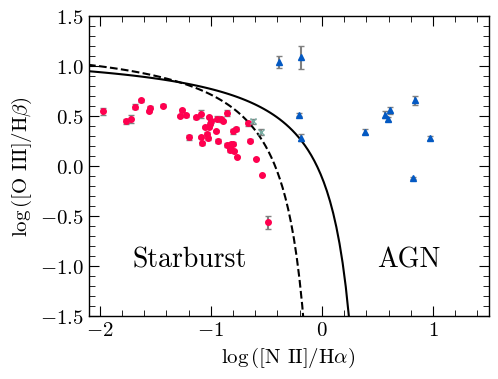

In [14]:
fig, ax = pf.create_plot()

ax.set_xlabel(r'$\log$([N II]/H$\alpha$)')
ax.set_ylabel(r'$\log$([O III]/H$\beta$)')

xvals = np.log10(tab['nii6583_flux']/tab['halpha_flux'])
yvals = np.log10(tab['oiii5007_flux']/tab['hbeta_flux'])

xerr = np.abs(xvals*np.sqrt( (tab['nii6583_flux_err']/tab['nii6583_flux'])**2 + (tab['halpha_flux_err']/tab['halpha_flux'])**2 ))
yerr = np.abs(yvals*np.sqrt( (tab['oiii5007_flux_err']/tab['oiii5007_flux'])**2 + (tab['hbeta_flux_err']/tab['hbeta_flux'])**2 ))

classf = lr.classify_bpt(xvals,yvals)
markers = ['o','x','^']
colors = ['#ff004f', "#77aca2", "#0359c3"]


for i,key in enumerate(list(classf.keys())):
    mask = classf.get(key)
    ax.errorbar(xvals[mask],yvals[mask], fmt=markers[i], yerr=yerr[mask], color=colors[i], ms=4, ecolor='gray', capsize=2)
ax.set_xlim(-2.1,1.5)
ax.set_ylim(-1.5,1.5)

grid = np.linspace(-2.5,0, 100)
grid2 = np.linspace(-2.5,.3, 100)

ax.plot(grid,lr.kauffmann03(grid),color='k', ls='--')
ax.plot(grid2,lr.kewley01(grid2),color='k')

ax.text(-1.7,-1,'Starburst', fontsize=20)
ax.text(0.5,-1,'AGN', fontsize=20)

pf.fix_plot([ax])
fig.savefig(f'figs/bpt_{fixed}.png', dpi=600, bbox_inches='tight')

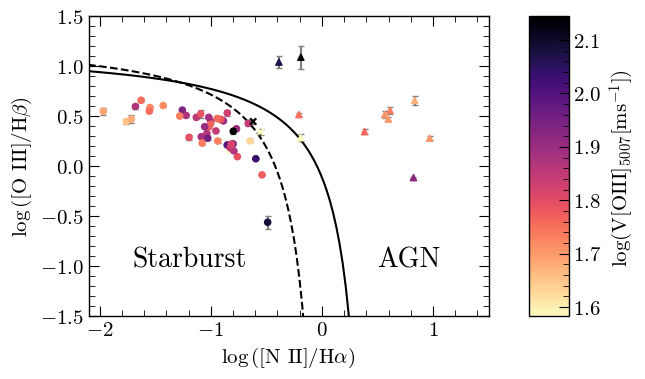

In [15]:
fig, ax = pf.create_plot()
ax2 = fig.add_axes((1.1,0,0.1,1))

ax.set_xlabel(r'$\log$([N II]/H$\alpha$)')
ax.set_ylabel(r'$\log$([O III]/H$\beta$)')

xvals = np.log10(tab['nii6583_flux']/tab['halpha_flux'])
yvals = np.log10(tab['oiii5007_flux']/tab['hbeta_flux'])

xerr = np.abs(xvals*np.sqrt( (tab['nii6583_flux_err']/tab['nii6583_flux'])**2 + (tab['halpha_flux_err']/tab['halpha_flux'])**2 ))
yerr = np.abs(yvals*np.sqrt( (tab['oiii5007_flux_err']/tab['oiii5007_flux'])**2 + (tab['hbeta_flux_err']/tab['hbeta_flux'])**2 ))

classf = lr.classify_bpt(xvals,yvals)
markers = ['o','x','^']
colors = ['#ff004f', "#77aca2", "#0359c3"]


for i,key in enumerate(list(classf.keys())):
    mask = classf.get(key)

    oiiiEW = tab['oiii5007_ew'][mask]
    oiiiDISP = tab['oiii5007_vel_disp'][mask]
    # hbetaDISP = tab['hbeta_vel_disp'][mask]

    # ax.errorbar(xvals[mask],yvals[mask], fmt=markers[i], yerr=yerr[mask], color=colors[i], ms=4, ecolor='gray', capsize=2)
    ax.errorbar(xvals[mask],yvals[mask], fmt='none', yerr=yerr[mask], ms=4, ecolor='gray', capsize=2)
    sc = ax.scatter(xvals[mask],yvals[mask], marker = markers[i], c=np.log10(oiiiDISP), s=20, zorder=10, cmap='magma_r')
    fig.colorbar(sc, ax=ax,cax=ax2, label=r'log(V[OIII]$_{5007}$[ms$^{-1}$]) ')

ax.set_xlim(-2.1,1.5)
ax.set_ylim(-1.5,1.5)

grid = np.linspace(-2.5,0, 100)
grid2 = np.linspace(-2.5,.3, 100)

ax.plot(grid,lr.kauffmann03(grid),color='k', ls='--')
ax.plot(grid2,lr.kewley01(grid2),color='k')

ax.text(-1.7,-1,'Starburst', fontsize=20)
ax.text(0.5,-1,'AGN', fontsize=20)

pf.fix_plot([ax,ax2])
fig.savefig(f'figs/bpt_vel_{fixed}.png', dpi=600, bbox_inches='tight')

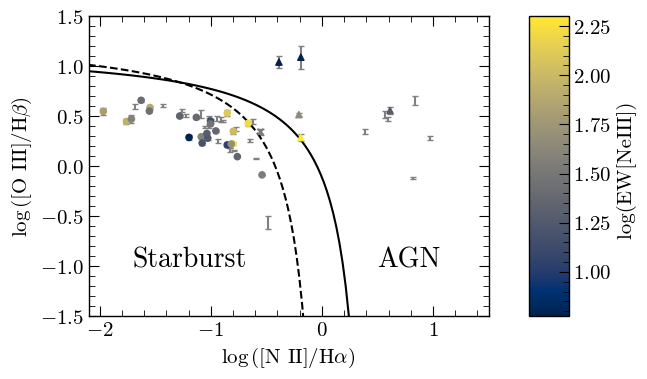

In [16]:
fig, ax = pf.create_plot()
ax2 = fig.add_axes((1.1,0,0.1,1))

ax.set_xlabel(r'$\log$([N II]/H$\alpha$)')
ax.set_ylabel(r'$\log$([O III]/H$\beta$)')

xvals = np.log10(tab['nii6583_flux']/tab['halpha_flux'])
yvals = np.log10(tab['oiii5007_flux']/tab['hbeta_flux'])

xerr = np.abs(xvals*np.sqrt( (tab['nii6583_flux_err']/tab['nii6583_flux'])**2 + (tab['halpha_flux_err']/tab['halpha_flux'])**2 ))
yerr = np.abs(yvals*np.sqrt( (tab['oiii5007_flux_err']/tab['oiii5007_flux'])**2 + (tab['hbeta_flux_err']/tab['hbeta_flux'])**2 ))

classf = lr.classify_bpt(xvals,yvals)
markers = ['o','x','^']
colors = ['#ff004f', "#77aca2", "#0359c3"]


for i,key in enumerate(list(classf.keys())):
    mask = classf.get(key)

    oiiiEW = tab['neiii_ew'][mask]
    # oiiiDISP = tab['oiii5007_vel_disp'][mask]

    # ax.errorbar(xvals[mask],yvals[mask], fmt=markers[i], yerr=yerr[mask], color=colors[i], ms=4, ecolor='gray', capsize=2)
    ax.errorbar(xvals[mask],yvals[mask], fmt='none', yerr=yerr[mask], ms=4, ecolor='gray', capsize=2)
    sc = ax.scatter(xvals[mask],yvals[mask], marker = markers[i], c=np.log10(oiiiEW), s=20, zorder=10, cmap='cividis')
    fig.colorbar(sc, ax=ax,cax=ax2, label=r'log(EW[NeIII]) ')

ax.set_xlim(-2.1,1.5)
ax.set_ylim(-1.5,1.5)

grid = np.linspace(-2.5,0, 100)
grid2 = np.linspace(-2.5,.3, 100)

ax.plot(grid,lr.kauffmann03(grid),color='k', ls='--')
ax.plot(grid2,lr.kewley01(grid2),color='k')

ax.text(-1.7,-1,'Starburst', fontsize=20)
ax.text(0.5,-1,'AGN', fontsize=20)

pf.fix_plot([ax,ax2])
fig.savefig(f'figs/bpt_neiiiew_{fixed}.png', dpi=600, bbox_inches='tight')

In [17]:
for i,key in enumerate(list(classf.keys())):
    mask = classf.get(key)

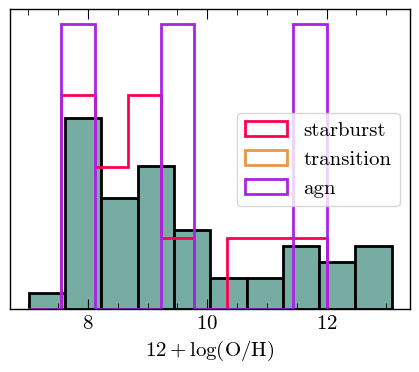

In [18]:
fig, ax = pf.create_plot()

colors = ['#ff004f', "#E89844", "#a923e7"]

for i,key in enumerate(list(classf.keys())):
    mask = classf.get(key)
    ax.hist(tab['Z_dir'][mask], lw=2, density=True, edgecolor=colors[i], histtype='step', label=key, bins=np.linspace(7,12,10))

ax.hist(tab['Z_dir'], lw=2, density=True, edgecolor='k', facecolor="#77aca2", zorder=-1)
pf.fix_plot([ax])
ax.set_yticks([])
ax.set_xlabel(r'$12+\log(\mathrm{O/H})$')
plt.legend()
fig.savefig(f'figs/metallicitypops.png', dpi=600, bbox_inches='tight')

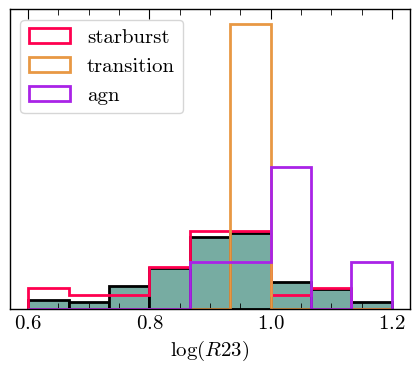

In [19]:
fig, ax = pf.create_plot()

colors = ['#ff004f', "#E89844", "#a923e7"]

for i,key in enumerate(list(classf.keys())):
    mask = classf.get(key)
    ax.hist(np.log10(R23)[mask], lw=2, density=True, edgecolor=colors[i], histtype='step', label=key, bins=np.linspace(0.6,1.2,10))

ax.hist(np.log10(R23), lw=2, density=True, edgecolor='k', facecolor="#77aca2", zorder=-1,bins=np.linspace(0.6,1.2,10))
pf.fix_plot([ax])
ax.set_yticks([])
ax.set_xlabel(r'$\log(R23)$')
plt.legend()
fig.savefig(f'figs/r23pops_{fixed}.png', dpi=600, bbox_inches='tight')

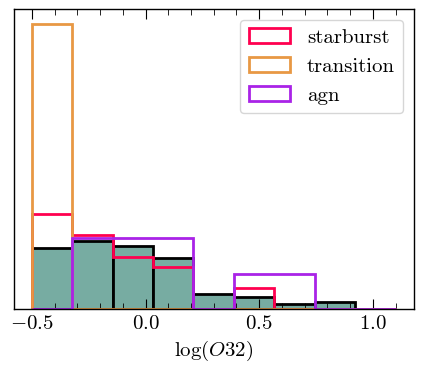

In [20]:
fig, ax = pf.create_plot()

colors = ['#ff004f', "#E89844", "#a923e7"]

for i,key in enumerate(list(classf.keys())):
    mask = classf.get(key)
    ax.hist(np.log10(O32)[mask], lw=2, density=True, edgecolor=colors[i], histtype='step', label=key, bins=np.linspace(-.5,1.1,10))

ax.hist(np.log10(O32), lw=2, density=True, edgecolor='k', facecolor="#77aca2", zorder=-1,bins=np.linspace(-.5,1.1,10))
pf.fix_plot([ax])
ax.set_yticks([])
ax.set_xlabel(r'$\log(O32)$')
plt.legend()
fig.savefig(f'figs/o32pops_{fixed}.png', dpi=600, bbox_inches='tight')

/var/folders/6b/x84gj0ds47n3hjglw1wq1j8m0000gn/T/ipykernel_64970/305735751.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


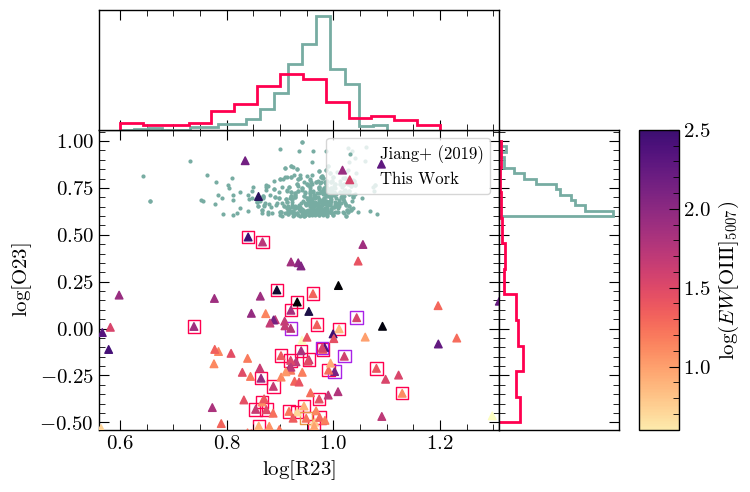

In [21]:
fig, ax = pf.create_plot()
ax.set_xlabel(r'$\log[\mathrm{R23}]$')
ax.set_ylabel(r'$\log[\mathrm{O23}]$')


ax1 = fig.add_axes([1,0,0.3,1], sharey=ax)
plt.setp(ax1.get_yticklabels(), visible=False)
ax2 = fig.add_axes([0,1,1,0.4], sharex=ax)
plt.setp(ax2.get_xticklabels(), visible=False)

cax = fig.add_axes([1.35,0,0.1,1])
cax.set_ylabel(r'$\log(EW\mathrm{[OIII]}_{5007})$')
cax.yaxis.set_label_position("right")

jiang_table = ascii.read('jiang_colorplot_data.csv')
O32_j = jiang_table['y']
R23_j = jiang_table['x']
cm = np.isfinite(tab['oiii5007_ew'])

ax.scatter(R23_j, O32_j, c='#77aca2', s=4, label='Jiang+ (2019)')
scatter = ax.scatter(np.log10(R23)[cm],np.log10(O32)[cm], s=30, marker='^',zorder=10, c=np.log10(tab['oiii5007_ew'])[cm], cmap='magma_r',vmax=3, vmin=.5, label='This Work')
cbar = fig.colorbar(scatter, ax=ax, cax=cax, label=r'$\log(EW\mathrm{[OIII]}_{5007})$')

colors = ['#ff004f', "#E89844", "#a923e7"]
for i,key in enumerate(list(classf.keys())):
    # mask = (classf.get(key))&(xvals<-1.8)
    mask = (classf.get(key))
    scatter = ax.scatter(np.log10(R23)[mask],np.log10(O32)[mask], s=80, marker='s', c='none', edgecolors=colors[i])


xlims = np.array([0.5,1.25])
ylims = np.array([-0.6,1])

ax.set_xlim(xlims+0.06)
ax.set_ylim(ylims+0.06)
ax1.set_xticks([])
ax2.set_yticks([])
cax.set_ylim(0.6,2.5)


ax1.hist(O32_j, bins=np.linspace(0.6,1,15), density=True, orientation='horizontal', histtype='step', lw=2, ec='#77aca2')
ax2.hist(R23_j, bins=np.linspace(0.6,1.1,20), density=True, orientation='vertical', histtype='step', lw=2, ec='#77aca2')

ax1.hist(np.log10(O32), bins=np.linspace(-0.5,1,12), density=True, orientation='horizontal', histtype='step', lw=2, ec='#ff004f')
ax2.hist(np.log10(R23), bins=np.linspace(0.6,1.2,15), density=True, orientation='vertical', histtype='step', lw=2, ec='#ff004f')

ax.legend(loc='upper right', fontsize=12)

pf.fix_plot([ax,ax1,ax2,cax])

plt.tight_layout()
plt.savefig(f'figs/r23o32_layered_{fixed}.png', dpi=600,bbox_inches='tight')

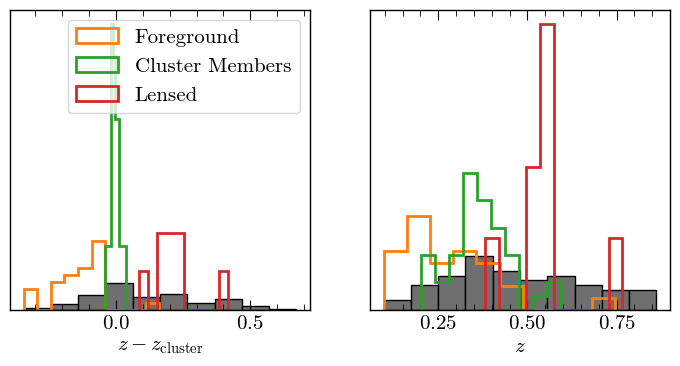

In [22]:
foreground = tab.group_by('foreground').groups[1]
cluster = tab.group_by('cluster_member').groups[1]
lensed = tab.group_by('lensed').groups[1]

groups = [foreground,cluster,lensed]
names = ['Foreground','Cluster Members','Lensed']

fig,ax=pf.create_plot(size=(3,3))
ax2 = fig.add_axes((1.2,0,1,1))

ax.set_yticks([])
ax2.set_yticks([])

ax.hist(tab['z']-tab['zcluster'], density=True, edgecolor='k',facecolor="#6F6F6F")
ax2.hist(tab['z'], density=True, edgecolor='k',facecolor="#6F6F6F")

for i,g in enumerate(groups):
    ax.hist(g['z']-g['zcluster'], density=True, histtype='step', lw=2, label=names[i])
    ax2.hist(g['z'], density=True, histtype='step', lw=2)

ax.set_xlabel(r'$z-z_{\mathrm{cluster}}$')
ax2.set_xlabel(r'$z$')

ax.legend()
pf.fix_plot([ax,ax2])
plt.savefig(f'figs/redshift_dist_{fixed}.png', dpi=600,bbox_inches='tight')

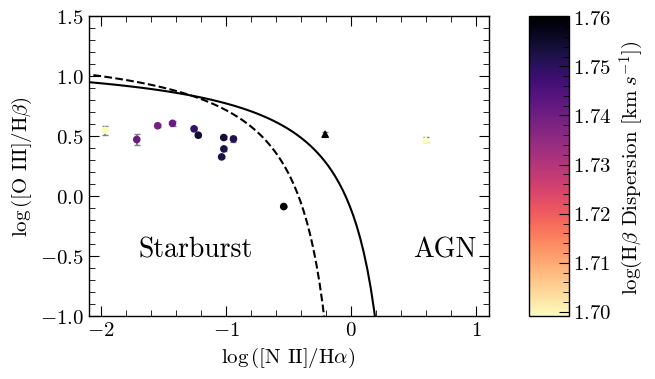

In [23]:
fig, ax = pf.create_plot()
ax2 = fig.add_axes((1.1,0,0.1,1))

ax.set_xlabel(r'$\log$([N II]/H$\alpha$)')
ax.set_ylabel(r'$\log$([O III]/H$\beta$)')

xvals = np.log10(tab['nii6583_flux']/tab['halpha_flux'])
yvals = np.log10(tab['oiii5007_flux']/tab['hbeta_flux'])

xerr = np.abs(xvals*np.sqrt( (tab['nii6583_flux_err']/tab['nii6583_flux'])**2 + (tab['halpha_flux_err']/tab['halpha_flux'])**2 ))
yerr = np.abs(yvals*np.sqrt( (tab['oiii5007_flux_err']/tab['oiii5007_flux'])**2 + (tab['hbeta_flux_err']/tab['hbeta_flux'])**2 ))

classf = lr.classify_bpt(xvals,yvals)
markers = ['o','x','^']
colors = ['#ff004f', "#77aca2", "#0359c3"]


for i,key in enumerate(list(classf.keys())):
    oiiiEW = tab['oiii5007_ew']
    hbetaEW = tab['hbeta_ew']
    mask = classf.get(key)&((oiiiEW>50)|(hbetaEW>50))
    # oiiiDISP = tab['oiii5007_vel_disp'][mask]
    hbetaDISP = tab['hbeta_vel_disp'][mask]
    # O32DISP = R23[mask]
    # ax.errorbar(xvals[mask],yvals[mask], fmt=markers[i], yerr=yerr[mask], color=colors[i], ms=4, ecolor='gray', capsize=2)
    ax.errorbar(xvals[mask],yvals[mask], fmt='none', yerr=yerr[mask], ms=4, ecolor='gray', capsize=2)
    sc = ax.scatter(xvals[mask],yvals[mask], marker = markers[i], c=np.log10(hbetaDISP), s=20, zorder=10, cmap='magma_r')
    fig.colorbar(sc, ax=ax,cax=ax2, label=r'log(H${\beta}$ Dispersion [km$\;s^{-1}$]) ')

ax.set_xlim(-2.1,1.1)
ax.set_ylim(-1,1.5)

grid = np.linspace(-2.5,0, 100)
grid2 = np.linspace(-2.5,.3, 100)

ax.plot(grid,lr.kauffmann03(grid),color='k', ls='--')
ax.plot(grid2,lr.kewley01(grid2),color='k')

ax.text(-1.7,-.5,'Starburst', fontsize=20)
ax.text(0.5,-.5,'AGN', fontsize=20)

pf.fix_plot([ax,ax2])
fig.savefig(f'figs/bpt_R23_{fixed}.png', dpi=600, bbox_inches='tight')

True

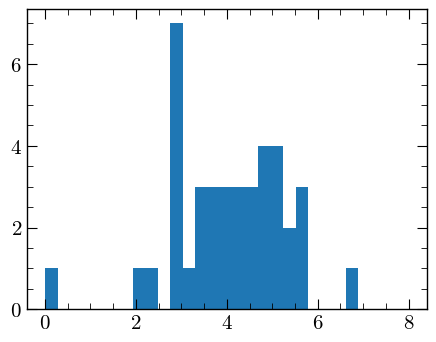

In [24]:
ratio = tab['oiii5007_flux']/tab['oiii4959_flux']
mask1 = np.isfinite(ratio)
mask2 = classf.get('starburst')

fig, ax = pf.create_plot()

ax.hist(ratio[mask1&mask2], bins = np.linspace(0,8,30))
# ax.scatter(tab['oiii5007_flux'],tab['oiii4959_flux'])

pf.fix_plot([ax])

True

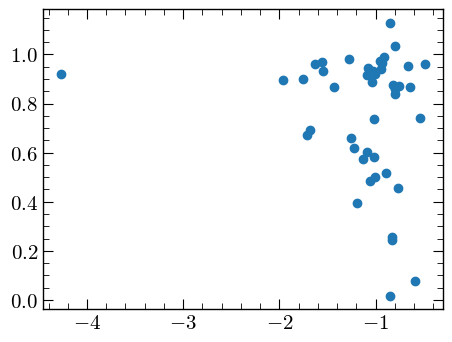

In [25]:
fig, ax = pf.create_plot()
mask3 = classf.get('starburst')
ax.scatter(xvals[mask3], np.log10(R23)[mask3])
pf.fix_plot([ax])

In [26]:
subtab = tab[classf.get('agn')].copy()
agns = Table([subtab['ra'], subtab['dec'], subtab['z'], subtab['name']])
agns.write('candidate_agns.csv', overwrite=True)

In [27]:
tab

object_id,ra,dec,z,angdisp,foreground,cluster_member,lensed,Z_dir,Z_dir_e,Z_j19,Z_j19_e,R23,R23_e,mean_vel_disp,sterr_vel_disp,zcluster,name,oiii5007_flux,oiii5007_flux_err,oiii5007_ew,oiii5007_ew_err,oiii5007_centroid,oiii5007_fwhm,oiii5007_vel_disp,oiii4959_flux,oiii4959_flux_err,oiii4959_ew,oiii4959_ew_err,oiii4959_centroid,oiii4959_fwhm,oiii4959_vel_disp,oii3726_flux,oii3726_flux_err,oii3726_ew,oii3726_ew_err,oii3726_centroid,oii3726_fwhm,oii3726_vel_disp,oii3729_flux,oii3729_flux_err,oii3729_ew,oii3729_ew_err,oii3729_centroid,oii3729_fwhm,oii3729_vel_disp,halpha_flux,halpha_flux_err,halpha_ew,halpha_ew_err,halpha_centroid,halpha_fwhm,halpha_vel_disp,hbeta_flux,hbeta_flux_err,hbeta_ew,hbeta_ew_err,hbeta_centroid,hbeta_fwhm,hbeta_vel_disp,hgamma_flux,hgamma_flux_err,hgamma_ew,hgamma_ew_err,hgamma_centroid,hgamma_fwhm,hgamma_vel_disp,hdelta_flux,hdelta_flux_err,hdelta_ew,hdelta_ew_err,hdelta_centroid,hdelta_fwhm,hdelta_vel_disp,hepsilon_flux,hepsilon_flux_err,hepsilon_ew,hepsilon_ew_err,hepsilon_centroid,hepsilon_fwhm,hepsilon_vel_disp,hzeta_flux,hzeta_flux_err,hzeta_ew,hzeta_ew_err,hzeta_centroid,hzeta_fwhm,hzeta_vel_disp,heta_flux,heta_flux_err,heta_ew,heta_ew_err,heta_centroid,heta_fwhm,heta_vel_disp,oiii4363_flux,oiii4363_flux_err,oiii4363_ew,oiii4363_ew_err,oiii4363_centroid,oiii4363_fwhm,oiii4363_vel_disp,neiii_flux,neiii_flux_err,neiii_ew,neiii_ew_err,neiii_centroid,neiii_fwhm,neiii_vel_disp,nii6583_flux,nii6583_flux_err,nii6583_ew,nii6583_ew_err,nii6583_centroid,nii6583_fwhm,nii6583_vel_disp,nii6548_flux,nii6548_flux_err,nii6548_ew,nii6548_ew_err,nii6548_centroid,nii6548_fwhm,nii6548_vel_disp,sii6716_flux,sii6716_flux_err,sii6716_ew,sii6716_ew_err,sii6716_centroid,sii6716_fwhm,sii6716_vel_disp,sii6731_flux,sii6731_flux_err,sii6731_ew,sii6731_ew_err,sii6731_centroid,sii6731_fwhm,sii6731_vel_disp,heii4686_flux,heii4686_flux_err,heii4686_ew,heii4686_ew_err,heii4686_centroid,heii4686_fwhm,heii4686_vel_disp,hei5876_flux,hei5876_flux_err,hei5876_ew,hei5876_ew_err,hei5876_centroid,hei5876_fwhm,hei5876_vel_disp
str29,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str12,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
28d07m28pt35s-28d53m18pt439s,28.124541666666662,-28.888455277777776,0.3685089804926993,26.18756698942221,1,0,0,nan,nan,8.141642654203588,0.004260300187639276,11.062827619803281,2.277642553607944,717.2840511320709,242.072037707888,0.4127,macs0152m28,4124.469894464831,87.899338157534,35.219154485348156,2.0501406651496796,5006.835951321285,2.000851928624639,47.66104780419961,1185.2825861364677,136.72975380269563,5.898970866095592,1.8880619600846873,4958.900222500991,1.6770166740703585,39.12405443693391,1761.464896696335,1068.6135356727189,29.998235596428906,91.72048342399984,3725.300846892047,5.449503026807009,184.65485291083476,2884.5577145722427,1618.3931634975047,49.243829643832576,138.90878074330303,3728.766711514383,5.449503026807009,184.516

(array([67., 41., 19., 12.,  7.,  3.,  2.,  1.,  2.,  1.,  1.,  2.,  0.,
         1.,  1.,  1.,  1.,  0.,  0.,  1.,  0.,  0.,  0.,  1.,  0.,  0.,
         0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.]),
 array([   0.        ,   20.40816327,   40.81632653,   61.2244898 ,
          81.63265306,  102.04081633,  122.44897959,  142.85714286,
         163.26530612,  183.67346939,  204.08163265,  224.48979592,
         244.89795918,  265.30612245,  285.71428571,  306.12244898,
         326.53061224,  346.93877551,  367.34693878,  387.75510204,
         408.16326531,  428.57142857,  448.97959184,  469.3877551 ,
         489.79591837,  510.20408163,  530.6122449 ,  551.02040816,
         571.42857143,  591.83673469,  612.24489796,  632.65306122,
         653.06122449,  673.46938776,  693.87755102,  714.28571429,
         734.69387755,  755.10204082,  775.51020408,  795.91836735,
         816.32653061,  836.73469388,  85

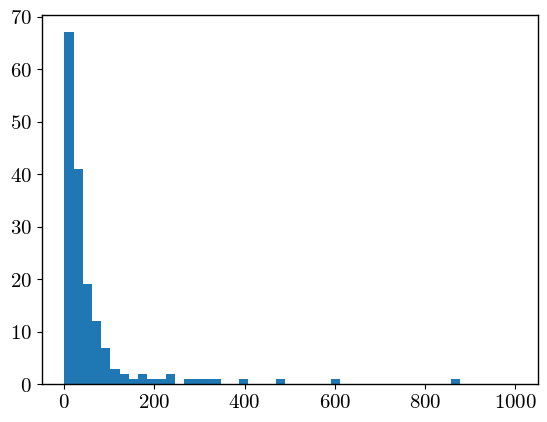

In [28]:
plt.hist(tab['oiii5007_ew'], bins=np.linspace(0,1000))

/var/folders/6b/x84gj0ds47n3hjglw1wq1j8m0000gn/T/ipykernel_64970/638950640.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


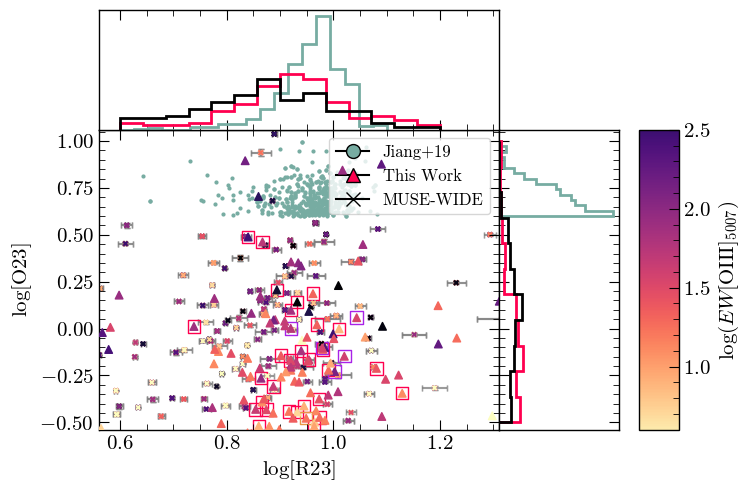

In [29]:
fig, ax = pf.create_plot()
ax.set_xlabel(r'$\log[\mathrm{R23}]$')
ax.set_ylabel(r'$\log[\mathrm{O23}]$')


ax1 = fig.add_axes([1,0,0.3,1], sharey=ax)
plt.setp(ax1.get_yticklabels(), visible=False)
ax2 = fig.add_axes([0,1,1,0.4], sharex=ax)
plt.setp(ax2.get_xticklabels(), visible=False)

cax = fig.add_axes([1.35,0,0.1,1])
cax.set_ylabel(r'$\log(EW\mathrm{[OIII]}_{5007})$')
cax.yaxis.set_label_position("right")

jiang_table = ascii.read('jiang_colorplot_data.csv')
O32_j = jiang_table['y']
R23_j = jiang_table['x']
cm = np.isfinite(tab['oiii5007_ew'])#&((tab['oiii5007_ew']>300)|(tab['hbeta_ew']>100))&((tab['oiii4363_flux']/np.abs(tab['oiii4363_flux_err']))>3)

ax.scatter(R23_j, O32_j, c='#77aca2', s=4, label='Jiang+ (2019)')
scatter = ax.scatter(np.log10(R23)[cm],np.log10(O32)[cm], s=30, marker='^',zorder=10, c=np.log10(tab['oiii5007_ew'])[cm], cmap='magma_r',vmax=3, vmin=.5, label='This Work')
cbar = fig.colorbar(scatter, ax=ax, cax=cax, label=r'$\log(EW\mathrm{[OIII]}_{5007})$')

colors = ['#ff004f', "#E89844", "#a923e7"]
for i,key in enumerate(list(classf.keys())):
    # mask = (classf.get(key))&(xvals<-1.8)
    mask = (classf.get(key))&cm
    scatter = ax.scatter(np.log10(R23)[mask],np.log10(O32)[mask], s=80, marker='s', c='none', edgecolors=colors[i])


xlims = np.array([0.5,1.25])
ylims = np.array([-0.6,1])

ax.set_xlim(xlims+0.06)
ax.set_ylim(ylims+0.06)
ax1.set_xticks([])
ax2.set_yticks([])
cax.set_ylim(0.6,2.5)


ax1.hist(O32_j, bins=np.linspace(0.6,1,15), density=True, orientation='horizontal', histtype='step', lw=2, ec='#77aca2')
ax2.hist(R23_j, bins=np.linspace(0.6,1.1,20), density=True, orientation='vertical', histtype='step', lw=2, ec='#77aca2')

ax1.hist(np.log10(O32), bins=np.linspace(-0.5,1,12), density=True, orientation='horizontal', histtype='step', lw=2, ec='#ff004f')
ax2.hist(np.log10(R23), bins=np.linspace(0.6,1.2,15), density=True, orientation='vertical', histtype='step', lw=2, ec='#ff004f')

poptable = ascii.read('poptable.csv')
cm2 = np.isfinite(poptable['oiiiEW'])#&((poptable['oiiiEW']>300)|(poptable['hbetaEW']>100))
ax.scatter(poptable['log10R23'][cm2], poptable['log10O32'][cm2],marker='x', s=10, c=np.log10(poptable['oiiiEW'])[cm2],cmap='magma_r',vmax=3, vmin=.5,label='MUSE-WIDE')
ax.errorbar(poptable['log10R23'][cm2],poptable['log10O32'][cm2],xerr=poptable['log10R23_e'][cm2]/10, yerr=poptable['log10O32_e'][cm2]/10, fmt='none', ecolor='gray', capsize=2, zorder=-10, alpha=0.4)

ax1.hist(poptable['log10O32'], bins=np.linspace(-0.5,1,12), density=True, orientation='horizontal', histtype='step', lw=2, ec='k')
ax2.hist(poptable['log10R23'], bins=np.linspace(0.6,1.2,15), density=True, orientation='vertical', histtype='step', lw=2, ec='k')

legend_elements = [
    Line2D([0], [0], marker='o', color='k', label='Jiang+19',
           markerfacecolor='#77aca2', markersize=10),
    Line2D([0], [0], marker='^', color='k', label='This Work',
           markerfacecolor='#ff004f', markersize=10),
    Line2D([0], [0], marker='x', color='k', label='MUSE-WIDE',
           markerfacecolor='#ff004f', markersize=10)
]


ax.legend(loc='upper right', fontsize=12, handles=legend_elements)

pf.fix_plot([ax,ax1,ax2,cax])

plt.tight_layout()
plt.savefig(f'figs/r23o32_layered_POP_{fixed}.png', dpi=600,bbox_inches='tight')

In [30]:
def get_j19(logR23, logO32):
    a = -24.691
    b = 6.3027
    c = -0.38856
    d = -0.146
    e = -7.110

    y=logO32
    discriminant = (b-d*y)**2 - 4*c*(a-d*e*y-logR23)

    logR23max = 0.862 + 0.155*y - 0.0143*y**2

    # if logR23>logR23max:
    #     return (d*y-b)/(2*c)
    # else:
    #     if y>0.5: #includes the >0.6 and the upper branch - applies for most galaxies
    #         return ((d*y-b)-np.sqrt(discriminant))/(2*c)
    #     else: #anything <0.5
    #         return ((d*y-b)+np.sqrt(discriminant))/(2*c)
        

    return np.where(
        logR23>logR23max,
        (d*y-b)/(2*c),
        np.where(
            y>0.5,
            ((d*y-b)-np.sqrt(discriminant))/(2*c),
            ((d*y-b)+np.sqrt(discriminant))/(2*c)
        )
    )

In [31]:
metal = get_j19(np.log10(R23), np.log10(O32))
metal_musewide = get_j19(poptable['log10R23'], poptable['log10O32'])

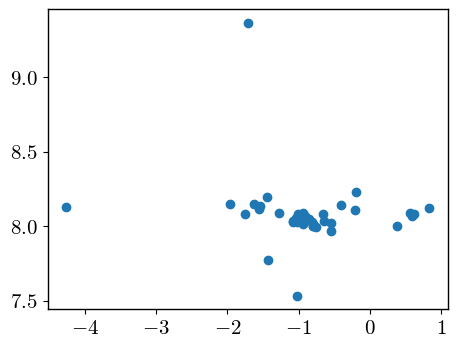

In [32]:
fig,ax = pf.create_plot()

ax.scatter(xvals, metal)


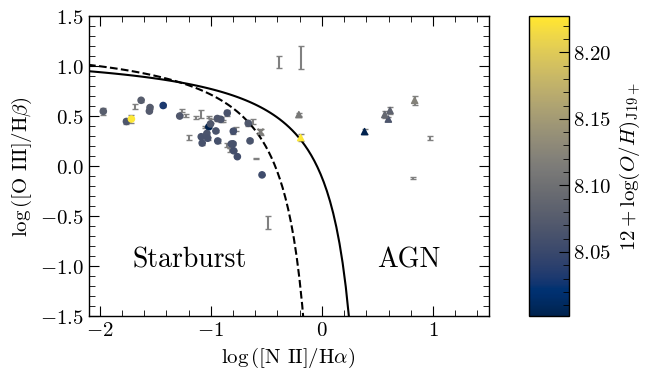

In [33]:
fig, ax = pf.create_plot()
ax2 = fig.add_axes((1.1,0,0.1,1))

ax.set_xlabel(r'$\log$([N II]/H$\alpha$)')
ax.set_ylabel(r'$\log$([O III]/H$\beta$)')

xvals = np.log10(tab['nii6583_flux']/tab['halpha_flux'])
yvals = np.log10(tab['oiii5007_flux']/tab['hbeta_flux'])

xerr = np.abs(xvals*np.sqrt( (tab['nii6583_flux_err']/tab['nii6583_flux'])**2 + (tab['halpha_flux_err']/tab['halpha_flux'])**2 ))
yerr = np.abs(yvals*np.sqrt( (tab['oiii5007_flux_err']/tab['oiii5007_flux'])**2 + (tab['hbeta_flux_err']/tab['hbeta_flux'])**2 ))

classf = lr.classify_bpt(xvals,yvals)
markers = ['o','x','^']
colors = ['#ff004f', "#77aca2", "#0359c3"]


for i,key in enumerate(list(classf.keys())):
    mask = classf.get(key)

    # oiiiDISP = tab['oiii5007_vel_disp'][mask]

    # ax.errorbar(xvals[mask],yvals[mask], fmt=markers[i], yerr=yerr[mask], color=colors[i], ms=4, ecolor='gray', capsize=2)
    ax.errorbar(xvals[mask],yvals[mask], fmt='none', yerr=yerr[mask], ms=4, ecolor='gray', capsize=2)
    sc = ax.scatter(xvals[mask],yvals[mask], marker = markers[i], c=metal[mask], s=20, zorder=10, cmap='cividis')
    fig.colorbar(sc, ax=ax,cax=ax2, label=r'$12+\log(O/H)_{\mathrm{J19+}}$')

ax.set_xlim(-2.1,1.5)
ax.set_ylim(-1.5,1.5)

grid = np.linspace(-2.5,0, 100)
grid2 = np.linspace(-2.5,.3, 100)

ax.plot(grid,lr.kauffmann03(grid),color='k', ls='--')
ax.plot(grid2,lr.kewley01(grid2),color='k')

ax.text(-1.7,-1,'Starburst', fontsize=20)
ax.text(0.5,-1,'AGN', fontsize=20)

pf.fix_plot([ax,ax2])
fig.savefig(f'figs/bpt_metals_{fixed}.png', dpi=600, bbox_inches='tight')

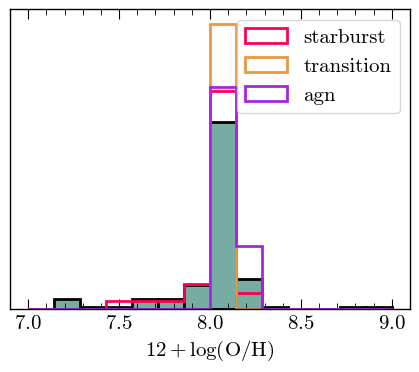

In [34]:
fig, ax = pf.create_plot()

colors = ['#ff004f', "#E89844", "#a923e7"]

for i,key in enumerate(list(classf.keys())):
    mask = classf.get(key)
    ax.hist(metal[mask], lw=2, density=True, edgecolor=colors[i], histtype='step', label=key, bins=np.linspace(7,9,15))

ax.hist(metal, lw=2, density=True, edgecolor='k', facecolor="#77aca2", zorder=-1, bins=np.linspace(7,9,15))
pf.fix_plot([ax])
ax.set_yticks([])
ax.set_xlabel(r'$12+\log(\mathrm{O/H})$')
plt.legend()
fig.savefig(f'figs/metallicitypops.png', dpi=600, bbox_inches='tight')

In [35]:
def calculate_log_n_log_s(table: Table, key = 'oiii5007_flux') -> tuple[np.ndarray, np.ndarray]:
    # Filter out sources with non-positive flux
    positive_flux_table = table[table[key] > 0]
    sorted_table = positive_flux_table.copy()
    sorted_table.sort(key, reverse=True)
    S = sorted_table[key]
    N = np.arange(1, len(sorted_table) + 1)
    log_S = np.log10(S)
    log_N = np.log10(N)
    return log_S, log_N


In [36]:
log_S,log_N = calculate_log_n_log_s(tab) 

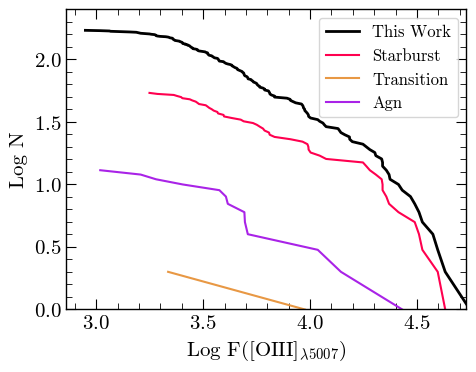

In [37]:
fig,ax = pf.create_plot()


ax.plot(log_S,log_N, color='k', lw=2, label='This Work')


for i,key in enumerate(list(classf.keys())):
    mask = classf.get(key)
    logs, logn =  calculate_log_n_log_s(tab[mask]) 
    ax.plot(logs,logn, color=colors[i], label=key.capitalize())

ax.set_xlim(2.86, 4.73)
ax.set_ylim(0,2.4)
ax.legend(fontsize=12)

ax.set_xlabel(r'Log F([OIII]$_{\lambda 5007}$)')
ax.set_ylabel('Log N')


pf.fix_plot([ax])
fig.savefig(f'figs/ns_classif_{fixed}.png', dpi=600, bbox_inches='tight')

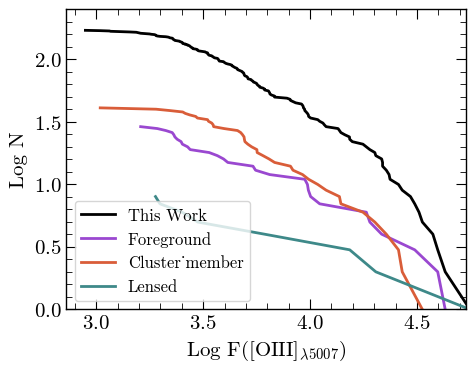

In [38]:
fig,ax = pf.create_plot()


ax.plot(log_S,log_N, color='k', lw=2, label='This Work')


for i,key in enumerate(['foreground','cluster_member','lensed']):
    mask = tab[key]==1
    logs, logn =  calculate_log_n_log_s(tab[mask]) 
    ax.plot(logs,logn, color=colours[i], label=key.capitalize(), lw=2)

ax.set_xlim(2.86, 4.73)
ax.set_ylim(0,2.4)
ax.legend(fontsize=12)

ax.set_xlabel(r'Log F([OIII]$_{\lambda 5007}$)')
ax.set_ylabel('Log N')


pf.fix_plot([ax])
fig.savefig(f'figs/lensing_{fixed}.png', dpi=600, bbox_inches='tight')

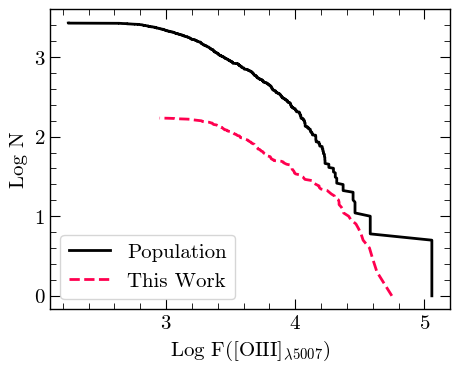

In [39]:
fig, ax = pf.create_plot()

mw_table = Table(ascii.read('musewide_sources.csv'))

logs_mw, logn_mw = calculate_log_n_log_s(mw_table, key = 'WFoiii5007_flux')

ax.plot(logs_mw,logn_mw,color='k', lw=2, label='Population', ls='-')
ax.plot(log_S,log_N, color='#ff004f', lw=2, label='This Work', ls='--')

ax.legend()
pf.fix_plot([ax])
ax.set_xlabel(r'Log F([OIII]$_{\lambda 5007}$)')
ax.set_ylabel('Log N')
fig.savefig(f'figs/ns_vsMW_{fixed}.png', dpi=600, bbox_inches='tight')

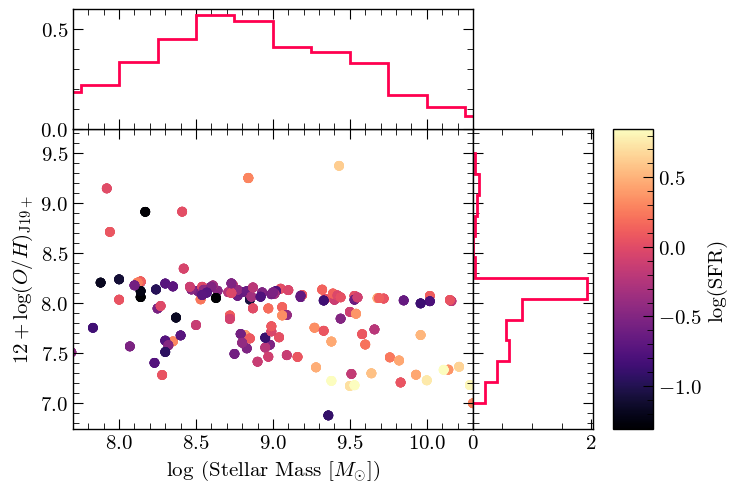

In [40]:
fig,ax = pf.create_plot(size=(4,3))
ax1 = fig.add_axes([1,0,0.3,1], sharey=ax)
plt.setp(ax1.get_yticklabels(), visible=False)
ax2 = fig.add_axes([0,1,1,0.4], sharex=ax)
plt.setp(ax2.get_xticklabels(), visible=False)

cax = fig.add_axes([1.35,0,0.1,1])

j19pop = get_j19(poptable['log10R23'], poptable['log10O32'])

sc = ax.scatter(poptable['Mstellar'], j19pop, c=poptable['SFR'], cmap='magma')
fig.colorbar(sc, ax=ax,cax=cax, label=r'log(SFR)')
ax.set_xlim(7.7,10.3)
ax.set_xlabel(r'$\log\;$(Stellar Mass [$M_{\odot}$])')
ax.set_ylabel(r'$12+\log(O/H)_{\mathrm{J19+}}$')

ax1.hist(j19pop, bins=np.linspace(7,9.5,13), orientation='horizontal', density=True, histtype='step', lw=2, color='#ff004f')
ax2.hist(poptable['Mstellar'], bins=np.linspace(7,11,17), orientation='vertical', density=True,histtype='step', lw=2, color='#ff004f')

pf.fix_plot([ax,ax1,ax2,cax])

fig.savefig(f'figs/ns_MWSFR_{fixed}.png', dpi=600, bbox_inches='tight')

/var/folders/6b/x84gj0ds47n3hjglw1wq1j8m0000gn/T/ipykernel_64970/615873245.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


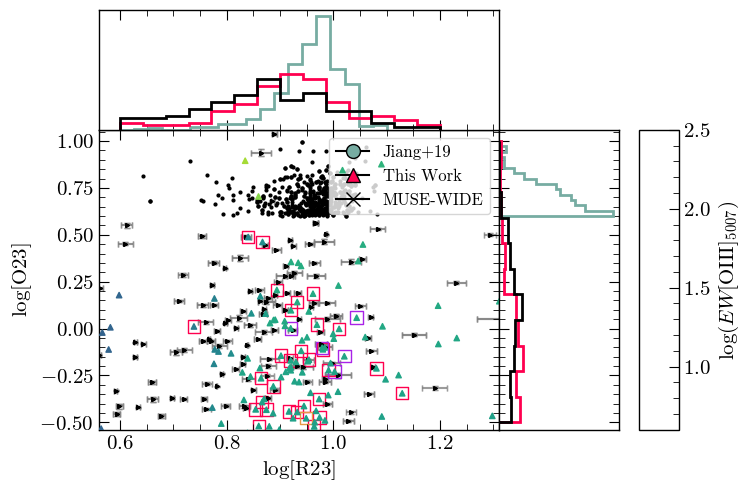

In [41]:
fig, ax = pf.create_plot()
ax.set_xlabel(r'$\log[\mathrm{R23}]$')
ax.set_ylabel(r'$\log[\mathrm{O23}]$')


ax1 = fig.add_axes([1,0,0.3,1], sharey=ax)
plt.setp(ax1.get_yticklabels(), visible=False)
ax2 = fig.add_axes([0,1,1,0.4], sharex=ax)
plt.setp(ax2.get_xticklabels(), visible=False)

cax = fig.add_axes([1.35,0,0.1,1])
cax.set_ylabel(r'$\log(EW\mathrm{[OIII]}_{5007})$')
cax.yaxis.set_label_position("right")

jiang_table = ascii.read('jiang_colorplot_data.csv')
O32_j = jiang_table['y']
R23_j = jiang_table['x']
cm = np.isfinite(tab['oiii5007_ew'])#&((tab['oiii5007_ew']>300)|(tab['hbeta_ew']>100))&((tab['oiii4363_flux']/np.abs(tab['oiii4363_flux_err']))>3)

ax.scatter(R23_j, O32_j, c='k', s=4, label='Jiang+ (2019)')
scatter = ax.scatter(np.log10(R23)[cm],np.log10(O32)[cm], s=15, marker='^',zorder=10, label='This Work', c=get_j19(np.log10(R23)[cm],np.log10(O32)[cm]))
cbar = fig.colorbar(scatter, ax=ax, cax=cax, label=r'$\log(EW\mathrm{[OIII]}_{5007})$')

colors = ['#ff004f', "#E89844", "#a923e7"]
for i,key in enumerate(list(classf.keys())):
    # mask = (classf.get(key))&(xvals<-1.8)
    mask = (classf.get(key))&cm
    scatter = ax.scatter(np.log10(R23)[mask],np.log10(O32)[mask], s=80, marker='s', c='none', edgecolors=colors[i])


xlims = np.array([0.5,1.25])
ylims = np.array([-0.6,1])

ax.set_xlim(xlims+0.06)
ax.set_ylim(ylims+0.06)
ax1.set_xticks([])
ax2.set_yticks([])
cax.set_ylim(0.6,2.5)


ax1.hist(O32_j, bins=np.linspace(0.6,1,15), density=True, orientation='horizontal', histtype='step', lw=2, ec='#77aca2')
ax2.hist(R23_j, bins=np.linspace(0.6,1.1,20), density=True, orientation='vertical', histtype='step', lw=2, ec='#77aca2')

ax1.hist(np.log10(O32), bins=np.linspace(-0.5,1,12), density=True, orientation='horizontal', histtype='step', lw=2, ec='#ff004f')
ax2.hist(np.log10(R23), bins=np.linspace(0.6,1.2,15), density=True, orientation='vertical', histtype='step', lw=2, ec='#ff004f')

poptable = ascii.read('poptable.csv')
cm2 = np.isfinite(poptable['oiiiEW'])#&((poptable['oiiiEW']>300)|(poptable['hbetaEW']>100))
ax.scatter(poptable['log10R23'][cm2], poptable['log10O32'][cm2],marker='>', s=5, c='k',label='MUSE-WIDE')
ax.errorbar(poptable['log10R23'][cm2],poptable['log10O32'][cm2],xerr=poptable['log10R23_e'][cm2]/10, yerr=poptable['log10O32_e'][cm2]/10, fmt='none', ecolor='gray', capsize=2, zorder=-10, alpha=0.4)

ax1.hist(poptable['log10O32'], bins=np.linspace(-0.5,1,12), density=True, orientation='horizontal', histtype='step', lw=2, ec='k')
ax2.hist(poptable['log10R23'], bins=np.linspace(0.6,1.2,15), density=True, orientation='vertical', histtype='step', lw=2, ec='k')

legend_elements = [
    Line2D([0], [0], marker='o', color='k', label='Jiang+19',
           markerfacecolor='#77aca2', markersize=10),
    Line2D([0], [0], marker='^', color='k', label='This Work',
           markerfacecolor='#ff004f', markersize=10),
    Line2D([0], [0], marker='x', color='k', label='MUSE-WIDE',
           markerfacecolor='#ff004f', markersize=10)
]


ax.legend(loc='upper right', fontsize=12, handles=legend_elements)

# xgrid = np.linspace(*xlims, 1000)
# ygrid = np.linspace(*ylims, 1000)

# X,Y = np.meshgrid(xgrid,ygrid)
# Z = get_j19(X,Y)
# cmash = ax.pcolormesh(X,Y,Z, vmax=8.5, vmin=7, zorder=-10)
# cbar = fig.colorbar(cmash, ax=ax, cax=cax, label=r'$\log(EW\mathrm{[OIII]}_{5007})$')
# levels = np.linspace(7,8.5,10)
# contour = ax.contour(X, Y, Z, levels=levels, colors='white', linewidths=0.7)

pf.fix_plot([ax,ax1,ax2,cax])

plt.tight_layout()
plt.savefig(f'figs/r23o32_layered_POP_{fixed}.png', dpi=600,bbox_inches='tight')

In [42]:
tab

object_id,ra,dec,z,angdisp,foreground,cluster_member,lensed,Z_dir,Z_dir_e,Z_j19,Z_j19_e,R23,R23_e,mean_vel_disp,sterr_vel_disp,zcluster,name,oiii5007_flux,oiii5007_flux_err,oiii5007_ew,oiii5007_ew_err,oiii5007_centroid,oiii5007_fwhm,oiii5007_vel_disp,oiii4959_flux,oiii4959_flux_err,oiii4959_ew,oiii4959_ew_err,oiii4959_centroid,oiii4959_fwhm,oiii4959_vel_disp,oii3726_flux,oii3726_flux_err,oii3726_ew,oii3726_ew_err,oii3726_centroid,oii3726_fwhm,oii3726_vel_disp,oii3729_flux,oii3729_flux_err,oii3729_ew,oii3729_ew_err,oii3729_centroid,oii3729_fwhm,oii3729_vel_disp,halpha_flux,halpha_flux_err,halpha_ew,halpha_ew_err,halpha_centroid,halpha_fwhm,halpha_vel_disp,hbeta_flux,hbeta_flux_err,hbeta_ew,hbeta_ew_err,hbeta_centroid,hbeta_fwhm,hbeta_vel_disp,hgamma_flux,hgamma_flux_err,hgamma_ew,hgamma_ew_err,hgamma_centroid,hgamma_fwhm,hgamma_vel_disp,hdelta_flux,hdelta_flux_err,hdelta_ew,hdelta_ew_err,hdelta_centroid,hdelta_fwhm,hdelta_vel_disp,hepsilon_flux,hepsilon_flux_err,hepsilon_ew,hepsilon_ew_err,hepsilon_centroid,hepsilon_fwhm,hepsilon_vel_disp,hzeta_flux,hzeta_flux_err,hzeta_ew,hzeta_ew_err,hzeta_centroid,hzeta_fwhm,hzeta_vel_disp,heta_flux,heta_flux_err,heta_ew,heta_ew_err,heta_centroid,heta_fwhm,heta_vel_disp,oiii4363_flux,oiii4363_flux_err,oiii4363_ew,oiii4363_ew_err,oiii4363_centroid,oiii4363_fwhm,oiii4363_vel_disp,neiii_flux,neiii_flux_err,neiii_ew,neiii_ew_err,neiii_centroid,neiii_fwhm,neiii_vel_disp,nii6583_flux,nii6583_flux_err,nii6583_ew,nii6583_ew_err,nii6583_centroid,nii6583_fwhm,nii6583_vel_disp,nii6548_flux,nii6548_flux_err,nii6548_ew,nii6548_ew_err,nii6548_centroid,nii6548_fwhm,nii6548_vel_disp,sii6716_flux,sii6716_flux_err,sii6716_ew,sii6716_ew_err,sii6716_centroid,sii6716_fwhm,sii6716_vel_disp,sii6731_flux,sii6731_flux_err,sii6731_ew,sii6731_ew_err,sii6731_centroid,sii6731_fwhm,sii6731_vel_disp,heii4686_flux,heii4686_flux_err,heii4686_ew,heii4686_ew_err,heii4686_centroid,heii4686_fwhm,heii4686_vel_disp,hei5876_flux,hei5876_flux_err,hei5876_ew,hei5876_ew_err,hei5876_centroid,hei5876_fwhm,hei5876_vel_disp
str29,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str12,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
28d07m28pt35s-28d53m18pt439s,28.124541666666662,-28.888455277777776,0.3685089804926993,26.18756698942221,1,0,0,nan,nan,8.141642654203588,0.004260300187639276,11.062827619803281,2.277642553607944,717.2840511320709,242.072037707888,0.4127,macs0152m28,4124.469894464831,87.899338157534,35.219154485348156,2.0501406651496796,5006.835951321285,2.000851928624639,47.66104780419961,1185.2825861364677,136.72975380269563,5.898970866095592,1.8880619600846873,4958.900222500991,1.6770166740703585,39.12405443693391,1761.464896696335,1068.6135356727189,29.998235596428906,91.72048342399984,3725.300846892047,5.449503026807009,184.65485291083476,2884.5577145722427,1618.3931634975047,49.243829643832576,138.90878074330303,3728.766711514383,5.449503026807009,184.516

In [43]:
r,a = query_hst_imaging(25.027199999999993,-34.172200555555555, return_orig=True)

In [44]:
r

intentType,obs_collection,provenance_name,instrument_name,project,filters,wavelength_region,target_name,target_classification,obs_id,s_ra,s_dec,dataproduct_type,proposal_pi,calib_level,t_min,t_max,t_exptime,em_min,em_max,obs_title,t_obs_release,proposal_id,proposal_type,sequence_number,s_region,jpegURL,dataURL,dataRights,mtFlag,srcDen,obsid,distance
str11,str5,str17,str10,str4,str9,str7,str32,str41,str73,float64,float64,str10,str17,int64,float64,float64,float64,float64,float64,str58,float64,str23,str7,int64,str998,str138,str133,str6,bool,float64,str9,float64
science,HST,HAP-SVM,ACS/WFC,HAP,F606W,OPTICAL,MACSJ0140.0-3410,CLUSTER OF GALAXIES;HIGH REDSHIFT CLUSTER,hst_10491_14_acs_wfc_f606w_j9fc14,25.02316666667,-34.17769444444,image,"Ebeling, Harald",3,53662.19548664,53662.26680631,1200.0,470.0,720.0,--,53662.41766202,10491,HAP,--,POLYGON 25.071727448341743 -34.19876686635551 25.00675341715326 -34.21723230186698 25.005746020547342 -34.21567658744845 24.992655988607513 -34.188465438733324 24.979775177056116 -34.16243353253454 25.012423749597087 -34.15369138696876 25.04373998405344 -34.14577413300489 25.055259724121765 -34.16686913282945 25.071727448341743 -34.19876686635551,mast:HST/product/hst_10491_14_acs_wfc_f606w_j9fc14_drc.jpg,mast:HST/product/hst_10491_14_acs_wfc_f606w_j9fc14_drc.fits,PUBLIC,False,nan,26402376,0.0


In [45]:
def calculate_log_n_log_s_column(column) -> tuple[np.ndarray, np.ndarray]:
    copy = column[column>0].copy()
    sorted_column = np.sort(copy)
    S = sorted_column
    N = np.arange(1, len(sorted_column) + 1)
    log_S = np.log10(S)
    log_N = np.log10(N)
    return log_S, log_N

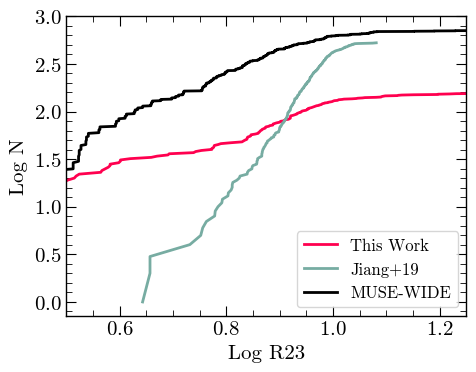

In [46]:
fig,ax = pf.create_plot()

S1,N1 = calculate_log_n_log_s_column(R23)
ax.plot(S1,N1, color='#ff004f', lw=2, label='This Work')

SJ,NJ = calculate_log_n_log_s_column(R23_j)
ax.plot(10**SJ,NJ, color='#77aca2', lw=2, label='Jiang+19')

SP,NP = calculate_log_n_log_s_column(poptable['log10R23'])
ax.plot(10**SP,NP, color='k', lw=2, label='MUSE-WIDE')

ax.legend(fontsize=12)

ax.set_xlabel(r'Log R23')
ax.set_ylabel('Log N')
xlims = np.array([0.5,1.25])
ax.set_xlim(*xlims)

pf.fix_plot([ax])
fig.savefig(f'figs/lensing_{fixed}.png', dpi=600, bbox_inches='tight')

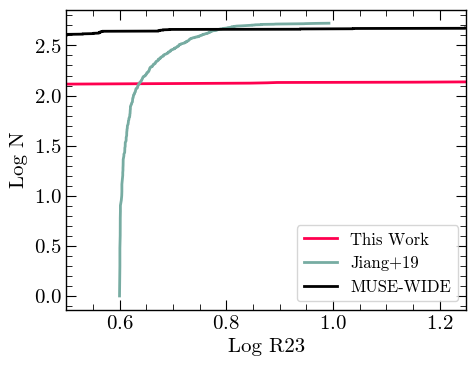

In [47]:
fig,ax = pf.create_plot()

S1,N1 = calculate_log_n_log_s_column(O32)
ax.plot(S1,N1, color='#ff004f', lw=2, label='This Work')

SJ,NJ = calculate_log_n_log_s_column(O32_j)
ax.plot(10**SJ,NJ, color='#77aca2', lw=2, label='Jiang+19')

SP,NP = calculate_log_n_log_s_column(poptable['log10O32'])
ax.plot(10**SP,NP, color='k', lw=2, label='MUSE-WIDE')

ax.legend(fontsize=12)

ax.set_xlabel(r'Log R23')
ax.set_ylabel('Log N')
xlims = np.array([0.5,1.25])
ax.set_xlim(*xlims)

pf.fix_plot([ax])
fig.savefig(f'figs/lensing_{fixed}.png', dpi=600, bbox_inches='tight')

/var/folders/6b/x84gj0ds47n3hjglw1wq1j8m0000gn/T/ipykernel_64970/4043309613.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


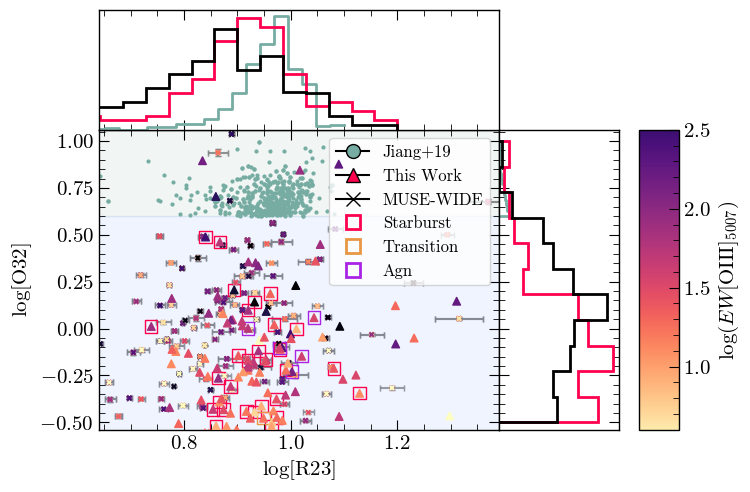

In [48]:
fig, ax = pf.create_plot()
ax.set_xlabel(r'$\log[\mathrm{R23}]$')
ax.set_ylabel(r'$\log[\mathrm{O32}]$')


ax1 = fig.add_axes([1,0,0.3,1], sharey=ax)
plt.setp(ax1.get_yticklabels(), visible=False)
ax2 = fig.add_axes([0,1,1,0.4], sharex=ax)
plt.setp(ax2.get_xticklabels(), visible=False)

cax = fig.add_axes([1.35,0,0.1,1])
cax.set_ylabel(r'$\log(EW\mathrm{[OIII]}_{5007})$')
cax.yaxis.set_label_position("right")

jiang_table = ascii.read('jiang_colorplot_data.csv')
O32_j = jiang_table['y']
R23_j = jiang_table['x']
cm = np.isfinite(tab['oiii5007_ew'])#&((tab['oiii5007_ew']>300)|(tab['hbeta_ew']>100))&((tab['oiii4363_flux']/np.abs(tab['oiii4363_flux_err']))>3)

ax.scatter(R23_j, O32_j, c='#77aca2', s=4, label='Jiang+ (2019)')
scatter = ax.scatter(np.log10(R23)[cm],np.log10(O32)[cm], s=30, marker='^',zorder=10, c=np.log10(tab['oiii5007_ew'])[cm], cmap='magma_r',vmax=3, vmin=.5, label='This Work')
cbar = fig.colorbar(scatter, ax=ax, cax=cax, label=r'$\log(EW\mathrm{[OIII]}_{5007})$')

colors = ['#ff004f', "#E89844", "#a923e7"]
for i,key in enumerate(list(classf.keys())):
    # mask = (classf.get(key))&(xvals<-1.8)
    mask = (classf.get(key))&cm
    scatter = ax.scatter(np.log10(R23)[mask],np.log10(O32)[mask], s=80, marker='s', c='none', edgecolors=colors[i], label=key)


xlims = np.array([0.5,1.25])
ylims = np.array([-0.6,1])

ax.set_xlim(xlims+0.06)
ax.set_ylim(ylims+0.06)
ax1.set_xticks([])
ax2.set_yticks([])
cax.set_ylim(0.6,2.5)


# ax1.hist(O32_j, bins=np.linspace(0.6,1,15), density=True, orientation='horizontal', histtype='step', lw=2, ec='#77aca2')
hist, bin_edges = np.histogram(O32_j, bins=np.linspace(0.6, 1, 15), density=True) 
ax1.step(np.concatenate(([0], hist/50)), bin_edges, where='post', lw=2, color='#77aca2')  

# ax2.hist(R23_j, bins=np.linspace(0.6,1.1,20), density=True, orientation='vertical', histtype='step', lw=2, ec='#77aca2')
hist, bin_edges = np.histogram(R23_j, bins=np.linspace(0.6,1.1,20), density=True) 
ax2.step( bin_edges,np.concatenate(([0], hist/2)), lw=2, color='#77aca2')  

ax1.hist(np.log10(O32), bins=np.linspace(-0.5,1,12), density=True, orientation='horizontal', histtype='step', lw=2, ec='#ff004f')
ax2.hist(np.log10(R23), bins=np.linspace(0.6,1.2,15), density=True, orientation='vertical', histtype='step', lw=2, ec='#ff004f')

poptable = ascii.read('poptable.csv')
cm2 = np.isfinite(poptable['oiiiEW'])#&((poptable['oiiiEW']>300)|(poptable['hbetaEW']>100))
ax.scatter(poptable['log10R23'][cm2], poptable['log10O32'][cm2],marker='x', s=10, c=np.log10(poptable['oiiiEW'])[cm2],cmap='magma_r',vmax=3, vmin=.5,label='MUSE-WIDE')
ax.errorbar(poptable['log10R23'][cm2],poptable['log10O32'][cm2],xerr=poptable['log10R23_e'][cm2]/10, yerr=poptable['log10O32_e'][cm2]/10, fmt='none', ecolor='gray', capsize=2, zorder=-10, alpha=0.4)

ax1.hist(poptable['log10O32'], bins=np.linspace(-0.5,1,12), density=True, orientation='horizontal', histtype='step', lw=2, ec='k')
ax2.hist(poptable['log10R23'], bins=np.linspace(0.6,1.2,15), density=True, orientation='vertical', histtype='step', lw=2, ec='k')

legend_elements = [
    Line2D([0], [0], marker='o', color='k', label='Jiang+19',
           markerfacecolor='#77aca2', markersize=10),
    Line2D([0], [0], marker='^', color='k', label='This Work',
           markerfacecolor='#ff004f', markersize=10),
    Line2D([0], [0], marker='x', color='k', label='MUSE-WIDE',
           markerfacecolor='#ff004f', markersize=10),     
]
for i,key in enumerate(list(classf.keys())):
    legend_elements.append(
        Line2D([0], [0], marker='s', color=colors[i], label=key.capitalize(),
           markerfacecolor='none', markersize=10, ls='none', mew=2),
    )


ax.fill_between([-100,100], 0.6,100, color='#77aca2', alpha=.1, zorder=-1)
ax.fill_between([-100,100], 0.6,-100, color="#6d99fa", alpha=.1, zorder=-1)

ax.legend(loc='upper right', fontsize=12, handles=legend_elements)

pf.fix_plot([ax,ax1,ax2,cax])

ax.set_xlim(0.64, 1.39)

plt.tight_layout()
plt.savefig(f'figs/r23o32_layered_POP1_{fixed}.png', dpi=600,bbox_inches='tight')

In [49]:
poptable

log10R23,log10R23_e,log10O32,log10O32_e,oiiiEW,hbetaEW,z,Mstellar,SFR
float64,float64,float64,float64,float64,float64,float64,float64,float64
nan,nan,nan,nan,nan,nan,4.793310165405273,0.0,nan
nan,nan,nan,nan,nan,nan,4.1996169090271,0.0,nan
nan,nan,nan,nan,nan,nan,4.439391136169434,0.0,nan
nan,nan,nan,nan,nan,nan,4.814822196960449,0.0,nan
nan,nan,nan,nan,nan,nan,4.9472455978393555,0.0,nan
nan,nan,nan,nan,nan,nan,3.1427299976348877,0.0,nan
nan,nan,nan,nan,nan,nan,3.0648000240325928,0.0,nan
nan,nan,nan,nan,nan,nan,3.065150022506714,0.0,nan
nan,nan,nan,nan,nan,nan,5.319019794464111,0.0,nan
